In [2]:
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from torch_geometric.datasets import BA2MotifDataset, BAShapes
from pytorch_lightning import Trainer

from bcosgnn.models import BinaryClassifierGNN
from bcosgnn.bcos_gnn import GNNCls
from bcosgnn.data.load_dataset import load_dataset, NamedDataset
from bcosgnn.data.splits import split_random

from torch_geometric.utils import to_networkx
from torch_geometric.data import Data
import networkx as nx

import torch
from torch_geometric.datasets import ExplainerDataset
from torch_geometric.datasets.graph_generator import BAGraph
import torch_geometric.transforms as T
import torch.nn.functional as F
from sklearn.model_selection import train_test_split

## Graph classification task on BA2Motif

In [15]:
dataset = BA2MotifDataset("../data")
# dataset = load_dataset(NamedDataset.SAUREUS, root="../data")
model =  BinaryClassifierGNN(dataset.num_node_features, dataset.num_edge_features, hidden_dim=20, num_layers=3, b=1, max_out=2, gnn_cls=GNNCls.BCOS_MPNN, fragment_pooling=False, lr=0.001, weight_decay=0.0, dropout=0.0)

train_idx, val_idx, test_idx = split_random(dataset)
train_dataset = dataset[train_idx]
test_dataset = dataset[test_idx]
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

trainer = Trainer(max_epochs=1000)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


{0: Text(0.02405166294629759, 0.11197192242955468, '0'),
 1: Text(-0.1618852650988212, 0.1397488062866717, '1'),
 2: Text(0.5006114652512176, -0.1440700033407186, '2'),
 3: Text(0.200290301712272, 0.05468501533943308, '3'),
 4: Text(0.7771922960233859, -0.11902717967592724, '4'),
 5: Text(0.23728324156993869, 0.2367169767297242, '5'),
 6: Text(-0.1267596306957173, -0.28960786621850987, '6'),
 7: Text(0.12859352301362273, 0.33862874425801953, '7'),
 8: Text(-0.05040910264070886, 0.3089226476283723, '8'),
 9: Text(-0.05200506098547448, 0.5450851706004641, '9'),
 10: Text(0.7393284499423312, -0.26041357791160274, '10'),
 11: Text(-0.22695594563849023, -0.5400255871854067, '11'),
 12: Text(-0.06989936629129244, -0.5281933348422375, '12'),
 13: Text(0.624497679847957, -0.48369441553006554, '13'),
 14: Text(-0.013585785584370727, 0.8098058349618774, '14'),
 15: Text(-0.1850890943591534, 0.775334044366498, '15'),
 16: Text(-0.3256456284089835, -0.41856602787579666, '16'),
 17: Text(0.67596965

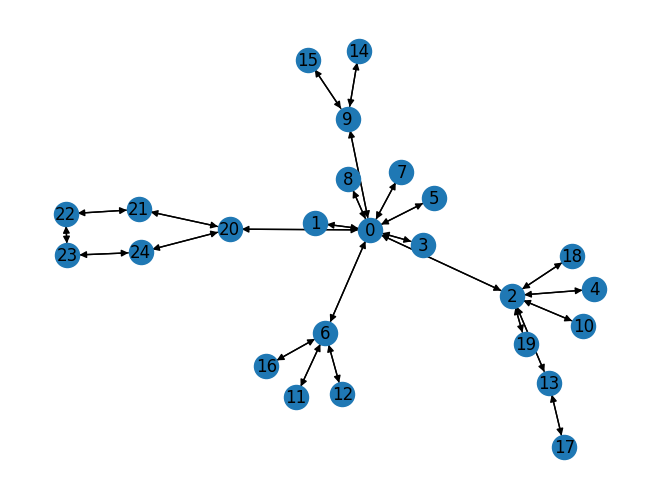

In [16]:
data = dataset[100]
g = to_networkx(data)
pos = nx.spring_layout(g)
nx.draw(g, pos)
nx.draw_networkx_labels(g, pos)

In [17]:
data = dataset[0]
out = model(data.x, data.edge_index)
print(out[0])

tensor([28.3181], grad_fn=<SelectBackward0>)


In [18]:
trainer.fit(model, train_dataloader)
trainer.test(model, test_dataloader)

trainer.save_checkpoint("../models/bcosgnn_motif_norm_d0.0.pt")


  | Name        | Type            | Params | Mode 
--------------------------------------------------------
0 | gnn_encoder | BcosMPNN        | 5.3 K  | train
1 | readout     | BcosReadout     | 840    | train
2 | recall      | BinaryRecall    | 0      | train
3 | precision   | BinaryPrecision | 0      | train
4 | auroc       | BinaryAUROC     | 0      | train
5 | accuracy    | BinaryAccuracy  | 0      | train
6 | train_acc   | BinaryAccuracy  | 0      | train
--------------------------------------------------------
6.2 K     Trainable params
0         Non-trainable params
6.2 K     Total params
0.025     Total estimated model params size (MB)
43        Modules in train mode
0         Modules in eval mode
c:\Projects\Python\bcosgnn\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoa

Epoch 11:  76%|███████▌  | 19/25 [00:00<00:00, 75.93it/s, v_num=58, train/loss=0.687, train/acc=0.561]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## Evaluate explanations

In [ ]:
def evaluate_explanations(model, root="../data", seed=42) -> float:
    dataset = BA2MotifDataset(root)

    _, _, test_idx = split_random(dataset, seed=seed)
    test_dataset = dataset[test_idx]
    test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    explanations = []
    for data in test_dataloader:
        explanation = model.explain(data)
        explanations.append(explanation)

    accuracies = []
    ground_truth = set(range(20,25))

    for explanation in explanations:
        exp = explanation["x"]["contribution_map"].sum(1)
        _, idx = torch.topk(exp, 5)
        idx = set(idx.tolist())
        acc = len(idx.intersection(ground_truth))/len(ground_truth)
        accuracies.append(acc)

    return sum(accuracies)/len(accuracies)

In [ ]:
model = BinaryClassifierGNN.load_from_checkpoint("../models/bcosgnn_motif_norm_d0.0.pt")
model.eval()

acc = evaluate_explanations(model)
print("Mean accuracy: ", acc)

Mean accuracy:  0.30400000000000005


In [ ]:
model = BinaryClassifierGNN.load_from_checkpoint("../models/bcosgnn_motif_norm_d0.0.pt")
model.eval()

acc = evaluate_explanations(model)
print("Mean accuracy: ", acc)

Mean accuracy:  0.30400000000000005


## Node classification task on BAShapes

In [ ]:
# Dataset


dataset = ExplainerDataset(
    graph_generator=BAGraph(num_nodes=300, num_edges=5),
    motif_generator='house',
    num_motifs=80,
    num_graphs=100,
    transform=T.Compose([T.Constant(0.1) for _ in range(10)]),
)
data = dataset[0]
idx = torch.arange(100)
train_idx, test_idx = train_test_split(idx, train_size=0.8, random_state=42)
# train_dataset = dataset[train_idx]
# test_dataset = dataset[test_idx]
# train_dataloader = DataLoader(train_dataset, batch_size=10, shuffle=True)
# test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

tensor([55, 88, 26, 42, 69, 15, 40, 96,  9, 72, 11, 47, 85, 28, 93,  5, 66, 65,
        35, 16, 49, 34,  7, 95, 27, 19, 81, 25, 62, 13, 24,  3, 17, 38,  8, 78,
         6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68, 61, 97, 79, 41, 58, 48,
        98, 57, 75, 32, 94, 59, 63, 84, 37, 29,  1, 52, 21,  2, 23, 87, 91, 74,
        86, 82, 20, 60, 71, 14, 92, 51])


torch.Size([700])


{0: Text(0.04023353382945061, 0.067879818379879, '0'),
 1: Text(-0.017773576080799103, 0.020954836159944534, '1'),
 2: Text(-0.00520272646099329, 0.011198243126273155, '2'),
 3: Text(-0.06280142068862915, -0.02573990821838379, '3'),
 4: Text(-0.03453826531767845, 0.020055707544088364, '4'),
 5: Text(0.01692962273955345, -0.08549368381500244, '5'),
 6: Text(-0.04655097424983978, 0.009133288636803627, '6'),
 7: Text(0.0019497837638482451, 0.001914454041980207, '7'),
 8: Text(-0.006787553429603577, -0.002477844012901187, '8'),
 9: Text(0.05076301842927933, 0.07720550894737244, '9'),
 10: Text(0.049858931452035904, -0.0161704383790493, '10'),
 11: Text(-0.015999767929315567, 0.023916389793157578, '11'),
 12: Text(-0.08956785500049591, 0.09522461146116257, '12'),
 13: Text(0.020703596994280815, -0.02172665111720562, '13'),
 14: Text(-0.07175544649362564, 0.073973648250103, '14'),
 15: Text(-0.008887596428394318, 0.0755850300192833, '15'),
 16: Text(-0.03403134271502495, -0.04456739872694015

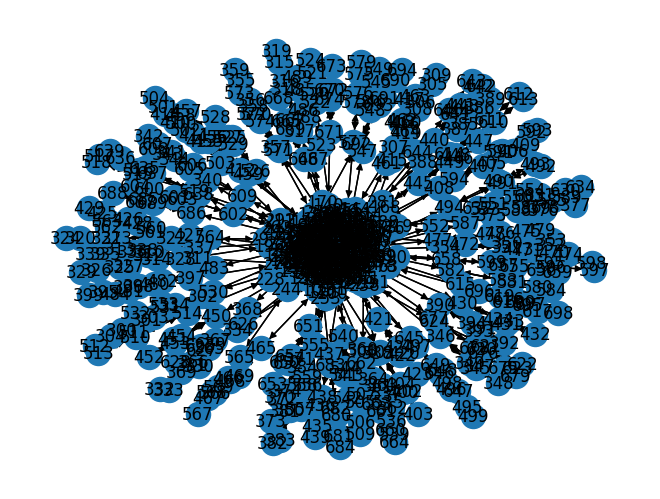

In [9]:
data = dataset[0]
print(data.y.shape)

# Draw graph
data = dataset[0]
g = to_networkx(data)
pos = nx.spring_layout(g)
nx.draw(g, pos)
nx.draw_networkx_labels(g, pos)

In [10]:
# Model
torch.manual_seed(42)

model =  BinaryClassifierGNN(dataset.num_node_features, 
                             dataset.num_edge_features, 
                             hidden_dim=20, 
                             num_layers=3, 
                             out_channels=4,
                             b=1, 
                             max_out=2, 
                             gnn_cls=GNNCls.BCOS_MPNN, 
                             fragment_pooling=False, 
                             lr=0.001, weight_decay=0.0, 
                             dropout=0.0, 
                             node_classification=True
                            )

c:\Projects\Python\bcosgnn\.venv\Lib\site-packages\torch\nn\init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [11]:
# Hyperparameters
epoch = 1000
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
model.train()
for epoch in range(epoch):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_idx], data.y[train_idx])
    loss.backward()
    optimizer.step()
    if(epoch % 100 == 0):
        print(f"Epoch {epoch}: Loss: {loss.item()}")

torch.save(model.state_dict(), f"../models/bcosgnn_node_classification_ba.pt")

# Train accuracy
model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)
correct = (pred[train_idx] == data.y[train_idx]).sum().item()
train_acc = correct / len(train_idx)
print(f"Train accuracy: {train_acc:.4f}")

# Test accuracy
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)
correct = (pred[test_idx] == data.y[test_idx]).sum().item()
test_acc = correct / len(test_idx)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 0: Loss: 1.4954092502593994
Epoch 100: Loss: 0.0027973544783890247
Epoch 200: Loss: 0.0010629590833559632
Epoch 300: Loss: 0.0005691174883395433
Epoch 400: Loss: 0.00035753860720433295
Epoch 500: Loss: 0.00024541435413993895
Epoch 600: Loss: 0.00017869661678560078
Epoch 700: Loss: 0.00013573440082836896
Epoch 800: Loss: 0.00010641842527547851
Epoch 900: Loss: 8.551261998945847e-05
Train accuracy: 1.0000
Test accuracy: 1.0000


In [16]:
def draw_contribution(model, data, node_index, k = 4):
    # Take largest 5 from contribution map
    explanation = model.explain(data, node_index)
    contributions = explanation["x"]["contribution_map"].sum(1)
    _, idx = torch.topk(contributions, 5)
    idx = idx.tolist()
    print(idx)

    g = to_networkx(data)
    pos = nx.spring_layout(g)
    nx.draw(g, pos)
    nx.draw_networkx_labels(g, pos)
    nx.draw_networkx_nodes(g, pos, nodelist=idx, node_color="r", node_size=100)
    nx.draw_networkx_nodes(g, pos, nodelist=[node_index], node_color="g", node_size=100)

[64, 8, 100, 285, 219]


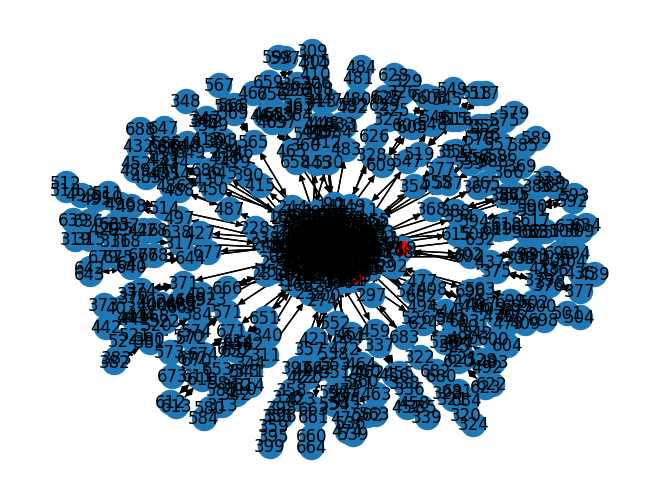

In [17]:
# Graph is too big to see, but the node being explained should be green and nodes contributing should be red
node_index = 64
draw_contribution(model, data, node_index)

In [15]:
node_indices = list(range(400, 500, 5))

accuracies = []

for node_index in node_indices:
    explanation = model.explain(data, node_index)
    ground_truth = list(range(node_index+1, node_index+5))

    contributions = explanation["x"]["contribution_map"].sum(1)
    _, idx = torch.topk(contributions, 5)
    idx = idx.tolist()
    acc = len(set(idx).intersection(ground_truth))/len(ground_truth)
    accuracies.append(acc)

print("Mean accuracy: ", sum(accuracies)/len(accuracies))
    

Mean accuracy:  0.925
